### Cantilever Beam — Demange-Chryst et al. (2022), Example 4.2

This notebook replicates the **cantilever beam** reliability-oriented
sensitivity analysis from Demange-Chryst et al. [1]. The goal is to
estimate Shapley effects for a structural engineering problem with
**correlated mixed-distribution inputs** (LogNormal + Normal).

**Model.** A rectangular cantilever beam under two orthogonal tip forces
$F_X$ and $F_Y$. The maximum vertical tip displacement is:

$$
D(\mathbf{x}) = \frac{4L^3}{E\,l_X l_Y}
\sqrt{\left(\frac{F_X}{l_X^2}\right)^2 +
      \left(\frac{F_Y}{l_Y^2}\right)^2}
$$

The failure threshold is $D > t = 0.066\,\text{m}$.

**Input variables** (6) with mixed Normal / LogNormal marginals and
correlations between the three dimensional parameters.

---
[1] Demange-Chryst, J., Bachoc, F., & Morio, J. (2022). "Shapley effect
estimation in reliability-oriented sensitivity analysis with correlated
inputs by importance sampling." *IJUQ*, arXiv:2202.12679.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


---
### Input Distribution

Six variables — three LogNormal forces/modulus, three correlated Normal
geometric parameters.  Correlations (Pearson): $\rho(l_X,l_Y)=0.55$,
$\rho(L,l_X)=\rho(L,l_Y)=0.45$.

In [2]:
d = 6

# Marginal parameters: (dist_type, mean, CV)
# LogNormal params converted to underlying normal (mu, sigma)
def lognorm_params(mean, cv):
    """Convert LogNormal (mean, CV) → underlying normal (mu, sigma)."""
    sigma = np.sqrt(np.log(1 + cv**2))
    mu = np.log(mean) - 0.5 * sigma**2
    return mu, sigma

def normal_params(mean, cv):
    """Convert Normal (mean, CV) → (mu, sigma)."""
    return mean, mean * cv

# Table 1 from the paper
marginals = {
    'FX': ('lognormal', *lognorm_params(556.8,       0.08)),
    'FY': ('lognormal', *lognorm_params(453.6,       0.08)),
    'E':  ('lognormal', *lognorm_params(200e9,       0.06)),
    'lX': ('normal',    *normal_params(0.062,        0.1)),
    'lY': ('normal',    *normal_params(0.0987,       0.1)),
    'L':  ('normal',    *normal_params(4.29,         0.1)),
}

labels = list(marginals.keys())
print(f"{'Variable':>6s}  {'Type':>10s}  {'Mean':>12s}  {'Std':>12s}")
print("-" * 48)
for name, (dist, mu, sigma) in marginals.items():
    if dist == 'lognormal':
        mn = np.exp(mu + 0.5 * sigma**2)
        st = mn * np.sqrt(np.exp(sigma**2) - 1)
    else:
        mn, st = mu, sigma
    print(f"{name:>6s}  {dist:>10s}  {mn:12.4g}  {st:12.4g}")

Variable        Type          Mean           Std
------------------------------------------------
    FX   lognormal         556.8         44.54
    FY   lognormal         453.6         36.29
     E   lognormal         2e+11       1.2e+10
    lX      normal         0.062        0.0062
    lY      normal        0.0987       0.00987
     L      normal          4.29         0.429


In [3]:
# Correlation matrix (Pearson) — only dimensional params are correlated
corr_pearson = np.eye(d)
# Indices: 0=FX, 1=FY, 2=E, 3=lX, 4=lY, 5=L
corr_pearson[3, 4] = corr_pearson[4, 3] = 0.55   # lX-lY
corr_pearson[3, 5] = corr_pearson[5, 3] = 0.45   # lX-L
corr_pearson[4, 5] = corr_pearson[5, 4] = 0.45   # lY-L

print("Pearson correlation matrix:")
print(pd.DataFrame(corr_pearson, index=labels, columns=labels).round(2))

Pearson correlation matrix:
     FX   FY    E    lX    lY     L
FX  1.0  0.0  0.0  0.00  0.00  0.00
FY  0.0  1.0  0.0  0.00  0.00  0.00
E   0.0  0.0  1.0  0.00  0.00  0.00
lX  0.0  0.0  0.0  1.00  0.55  0.45
lY  0.0  0.0  0.0  0.55  1.00  0.45
L   0.0  0.0  0.0  0.45  0.45  1.00


---
### Gaussian Copula Distribution Class

To handle mixed LogNormal + Normal marginals with correlation, we
build a **Gaussian copula** wrapper: transform each marginal to a
standard normal via the probability integral transform, apply the
correlation structure in the latent normal space, then map back.

For the Normal marginals (lX, lY, L), Pearson correlations in the
original space equal the latent normal correlations.  The LogNormal
variables (FX, FY, E) are uncorrelated, so the latent correlation
matrix is the identity for that block.

In [4]:
class GaussianCopulaMixed:
    """Gaussian copula with arbitrary marginal distributions.

    Supports LogNormal and Normal marginals with a user-specified
    latent correlation matrix.  Conditional sampling is performed
    in the latent normal space using the multivariate normal
    conditional distribution, then mapped back to the original space.
    """
    def __init__(self, marginals, latent_corr):
        self.d = len(marginals)
        self.labels = list(marginals.keys())
        self._marginals = marginals
        self._latent_corr = np.asarray(latent_corr)

        # Underlying multivariate normal for latent-space sampling
        self._mvn = MultivariateNormal(
            mean=np.zeros(self.d), cov=self._latent_corr
        )

    @staticmethod
    def _marginal_to_latent(x, dist, mu, sigma):
        """Transform a single marginal column original -> N(0,1)."""
        if dist == "lognormal":
            x = np.clip(np.asarray(x), 1e-15, None)
            return norm.ppf(lognorm.cdf(x, s=sigma, scale=np.exp(mu)))
        else:
            return (np.asarray(x) - mu) / sigma

    @staticmethod
    def _marginal_from_latent(z, dist, mu, sigma):
        """Transform a single marginal column N(0,1) -> original."""
        if dist == "lognormal":
            return lognorm.ppf(norm.cdf(np.asarray(z)), s=sigma, scale=np.exp(mu))
        else:
            return mu + sigma * np.asarray(z)

    def _to_original(self, Z):
        """Transform latent normal -> original space, vectorised."""
        X = np.zeros_like(Z)
        for j in range(self.d):
            name = self.labels[j]
            dist, mu, sigma = self._marginals[name]
            X[:, j] = self._marginal_from_latent(Z[:, j], dist, mu, sigma)
        return X

    def sample_joint(self, n):
        """Draw n joint samples."""
        Z = self._mvn.sample_joint(n)
        return self._to_original(Z)

    def sample_conditional(self, u_indices, fixed_x):
        """Draw one conditional sample."""
        X = self.sample_conditional_batch(
            u_indices, np.atleast_2d(np.asarray(fixed_x, dtype=float))
        )
        return X[0]

    def sample_conditional_batch(self, u_indices, fixed_X):
        """Draw N conditional samples.

        Strategy: map fixed_X to latent space, condition in the
        latent multivariate normal, map the result back.
        """
        u = np.asarray(u_indices)
        N = fixed_X.shape[0]
        fixed_X = np.asarray(fixed_X, dtype=float)

        if len(u) == 0:
            return self.sample_joint(N)

        # Map fixed variables to latent space
        Z_fixed = np.zeros((N, len(u)))
        for k, idx in enumerate(u):
            name = self.labels[idx]
            dist, mu, sigma = self._marginals[name]
            Z_fixed[:, k] = self._marginal_to_latent(
                fixed_X[:, k], dist, mu, sigma
            )

        # Condition in latent normal space
        Z_cond = self._mvn.sample_conditional_batch(u, Z_fixed)

        # Map back to original space
        return self._to_original(Z_cond)


joint = GaussianCopulaMixed(marginals, corr_pearson)
print("GaussianCopulaMixed distribution ready.")
print(f"Dimension: {joint.d}")

GaussianCopulaMixed distribution ready.
Dimension: 6


---
### Quick Validation: Empirical Correlations

Verify that the copula reproduces the specified Pearson correlations.

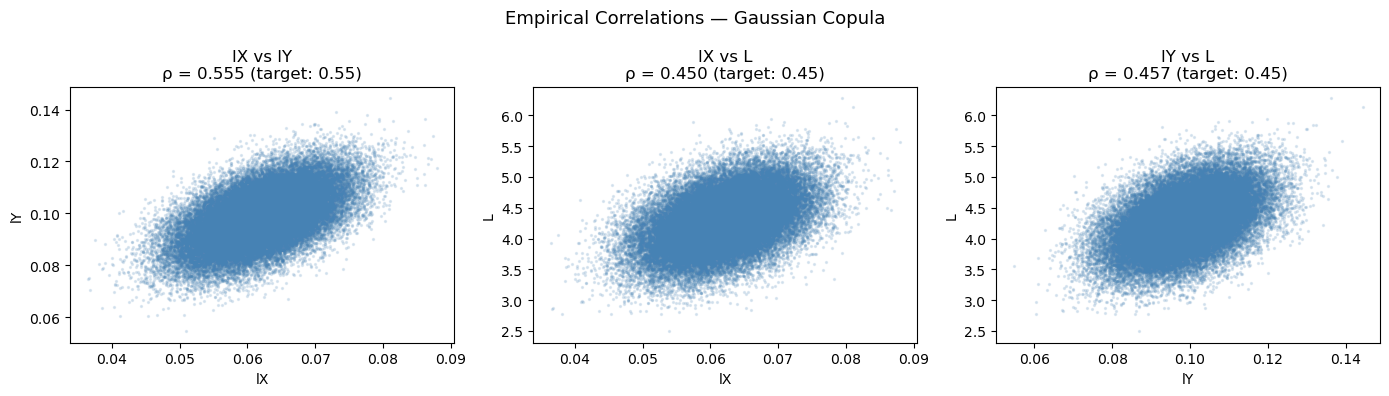

In [5]:
X_check = joint.sample_joint(50000)
emp_corr = np.corrcoef(X_check.T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [(3, 4, 'lX vs lY'), (3, 5, 'lX vs L'), (4, 5, 'lY vs L')]
for ax, (i, j, title) in zip(axes, pairs):
    ax.scatter(X_check[:, i], X_check[:, j], alpha=0.15, s=2, color='steelblue')
    ax.set_title(f'{title}\n'
                 f'ρ = {emp_corr[i,j]:.3f} (target: {corr_pearson[i,j]:.2f})')
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
plt.suptitle('Empirical Correlations — Gaussian Copula', fontsize=13)
plt.tight_layout()
plt.show()

---
### Cantilever Beam Deflection Model

The analytical displacement formula, Eq. (32) from the paper.

In [6]:
def cantilever_deflection(x):
    """Maximum vertical tip displacement (1D input)."""
    FX, FY, E, lX, lY, L = x
    if lX <= 0 or lY <= 0 or E <= 0:
        return 1e10  # penalty for unphysical values
    term = np.sqrt((FX / lX**2)**2 + (FY / lY**2)**2)
    return (4 * L**3) / (E * lX * lY) * term


def cantilever_deflection_batch(X):
    """Vectorised deflection for batch evaluation."""
    FX, FY = X[:, 0], X[:, 1]
    E = X[:, 2]
    lX, lY, L = X[:, 3], X[:, 4], X[:, 5]

    # Guard against unphysical values
    mask = (lX > 0) & (lY > 0) & (E > 0)
    D = np.full(len(X), 1e10)
    term = np.sqrt((FX[mask] / lX[mask]**2)**2
                   + (FY[mask] / lY[mask]**2)**2)
    D[mask] = (4 * L[mask]**3) / (E[mask] * lX[mask] * lY[mask]) * term
    return D


t = 0.066  # failure threshold (m)
print(f"Failure threshold: D > {t} m")

Failure threshold: D > 0.066 m


Estimated failure probability: 0.0748


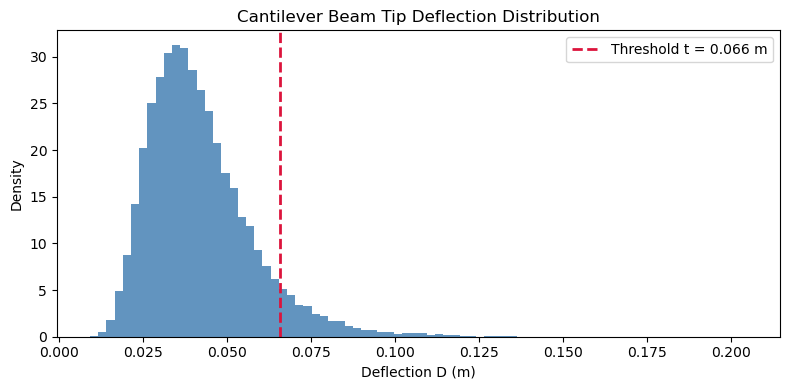

In [7]:
# Quick histogram of deflection values
D_sample = cantilever_deflection_batch(X_check[:20000])
D_sample = D_sample[D_sample < 1e9]  # remove penalty values

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(D_sample, bins=80, density=True, color='steelblue', alpha=0.85)
ax.axvline(t, color='crimson', linestyle='--', linewidth=2, label=f'Threshold t = {t} m')
ax.set_xlabel('Deflection D (m)')
ax.set_ylabel('Density')
ax.set_title('Cantilever Beam Tip Deflection Distribution')
ax.legend()
pf_est = np.mean(D_sample > t)
print(f"Estimated failure probability: {pf_est:.4f}")
plt.tight_layout()
plt.show()

---
### Variance-Based Shapley Effects (on Deflection $D$)

First, we compute **standard (variance-based) Shapley effects** on
the continuous deflection $D$.  This tells us which inputs drive
the *magnitude* of the deflection.

The exhaustive method is used with $N = 10{,}000$ samples and
$B = 200$ bootstrap replications.

In [8]:
eff, sh, var, lower, upper = shapley_effects(
    cantilever_deflection,
    joint,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    predict_batch=cantilever_deflection_batch,
    random_state=42,
    progress=True,
)

results = pd.DataFrame({
    'Variable': labels,
    'Effect': eff,
    'Lower': lower,
    'Upper': upper,
})
results

MC Shapley: 100%|██████████| 1250000/1250000 [00:00<00:00, 1451442.42evals/s]


,Variable,Effect,Lower,Upper
0,FX,0.044050,0.033502,0.055011
1,FY,0.008117,-0.005935,0.021244
2,E,0.033382,0.021038,0.044084
3,lX,0.431740,0.415193,0.448269
4,lY,0.153618,0.144380,0.161829
5,L,0.329093,0.317461,0.342106


---
### Target Shapley Effects (on Failure Indicator $\mathbf{1}_{D>t}$)

The paper computes **target (reliability-oriented) Shapley effects**
on the binary failure indicator $\mathbf{1}_{D>t}$.  This answers:
*which inputs are most responsible for pushing the beam into failure?*

We define a binary model function and run the same MC Shapley
estimation on it.

In [9]:
def failure_indicator(x):
    """Binary failure: 1 if deflection exceeds threshold, else 0."""
    D = cantilever_deflection(x)
    return 1.0 if D > t else 0.0


def failure_indicator_batch(X):
    """Vectorised failure indicator."""
    D = cantilever_deflection_batch(X)
    return (D > t).astype(float)


# Estimate failure probability from a large sample
X_pf = joint.sample_joint(200000)
pf_est = failure_indicator_batch(X_pf).mean()
print(f"Estimated failure probability: {pf_est:.4f}  (paper: ~0.015)")
print(f"Expected failures in N=10000: {10000 * pf_est:.0f}")

Estimated failure probability: 0.0739  (paper: ~0.015)
Expected failures in N=10000: 739


In [10]:
# Target Shapley effects on the binary failure indicator
# Note: with pf ~ 1-7%, enough failure samples exist for reasonable estimation
eff_t, sh_t, var_t, lower_t, upper_t = shapley_effects(
    failure_indicator,
    joint,
    N=100000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    predict_batch=failure_indicator_batch,
    random_state=42,
    progress=True,
)

results_target = pd.DataFrame({
    'Variable': labels,
    'Target Shapley': eff_t,
    'Lower': lower_t,
    'Upper': upper_t,
})
results_target

MC Shapley: 100%|██████████| 12500000/12500000 [00:09<00:00, 1340319.45evals/s]


,Variable,Target Shapley,Lower,Upper
0,FX,0.066017,0.061857,0.070748
1,FY,0.005433,-0.000200,0.011681
2,E,0.051893,0.047844,0.055671
3,lX,0.415238,0.408818,0.420742
4,lY,0.141739,0.137383,0.145187
5,L,0.319680,0.316063,0.323441


---
### RS-HDMR Surrogate Model

To demonstrate the surrogate-based workflow, we train an **RS-HDMR**
model on uniformly sampled data covering the practical range of each
input variable (approximately $\\mu \\pm 5\\sigma$).  The surrogate
is then used as the model function for MC Shapley estimation.

This tests whether a surrogate trained on independent uniform samples
can recover accurate Shapley effects under the *correlated*
mixed-distribution deployment.

In [ ]:
# Generate uniform training data across practical input ranges
np.random.seed(123)
N_train = 512

# Ranges covering ~mean +/- 5 sigma for each variable
ranges = {
    'FX': (350, 850),          # LogNormal(556.8, CV=0.08)
    'FY': (280, 700),          # LogNormal(453.6, CV=0.08)
    'E':  (1.4e11, 2.8e11),   # LogNormal(2e11, CV=0.06)
    'lX': (0.025, 0.100),      # Normal(0.062, CV=0.1)
    'lY': (0.040, 0.160),      # Normal(0.0987, CV=0.1)
    'L':  (2.0, 7.0),          # Normal(4.29, CV=0.1)
}

# Draw uniform samples
X_unif = np.column_stack([
    np.random.uniform(*ranges[name], N_train)
    for name in labels
])
Y_train = cantilever_deflection_batch(X_unif)

# Build DataFrame for RS-HDMR
df_train = pd.DataFrame(X_unif, columns=labels)
df_train['Y'] = Y_train

print(f"{len(df_train)} training samples")
print(f"Y range: [{Y_train.min():.4f}, {Y_train.max():.4f}] m")
print(f"Failure fraction (D > {t}): {(Y_train > t).mean():.3f}")

In [ ]:
from shapleyx import rshdmr

# Fit RS-HDMR surrogate
model = rshdmr(
    df_train,
    polys=[8, 6, 4],         # up to 3rd-order interactions
    n_iter=100,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.005,
)

sob_surr, shap_surr, total_surr = model.run_all()

In [ ]:
# MC Shapley using the surrogate model with the correlated distribution
mc_surrogate = model.get_mc_shapley(
    joint=joint,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
mc_surrogate

---
### Comparison: All Three Sets

Now we compare:
1. **Variance-based Shapley** (on $D$) — this work
2. **Target Shapley** (on $\mathbf{1}_{D>t}$) — this work
3. **Target Shapley reference** — from the paper (Table 2)

In [11]:
# Reference target Shapley effects from the paper (Table 2)
ref_target_shap = np.array([0.146, 0.001, 0.103, 0.282, 0.254, 0.214])

comparison = pd.DataFrame({
    'Variable': labels,
    'Var.-based (D, analytical)': eff.round(4),
    'Target (1_{D>t}, analytical)': eff_t.round(4),
    'Var.-based (D, surrogate)': mc_surrogate['effect'].values.round(4),
    'Paper target': ref_target_shap.round(3),
})
comparison

,Variable,Var.-based (D),Target (1_{D>t}),Paper target
0,FX,0.0440,0.0660,0.146
1,FY,0.0081,0.0054,0.001
2,E,0.0334,0.0519,0.103
3,lX,0.4317,0.4152,0.282
4,lY,0.1536,0.1417,0.254
5,L,0.3291,0.3197,0.214


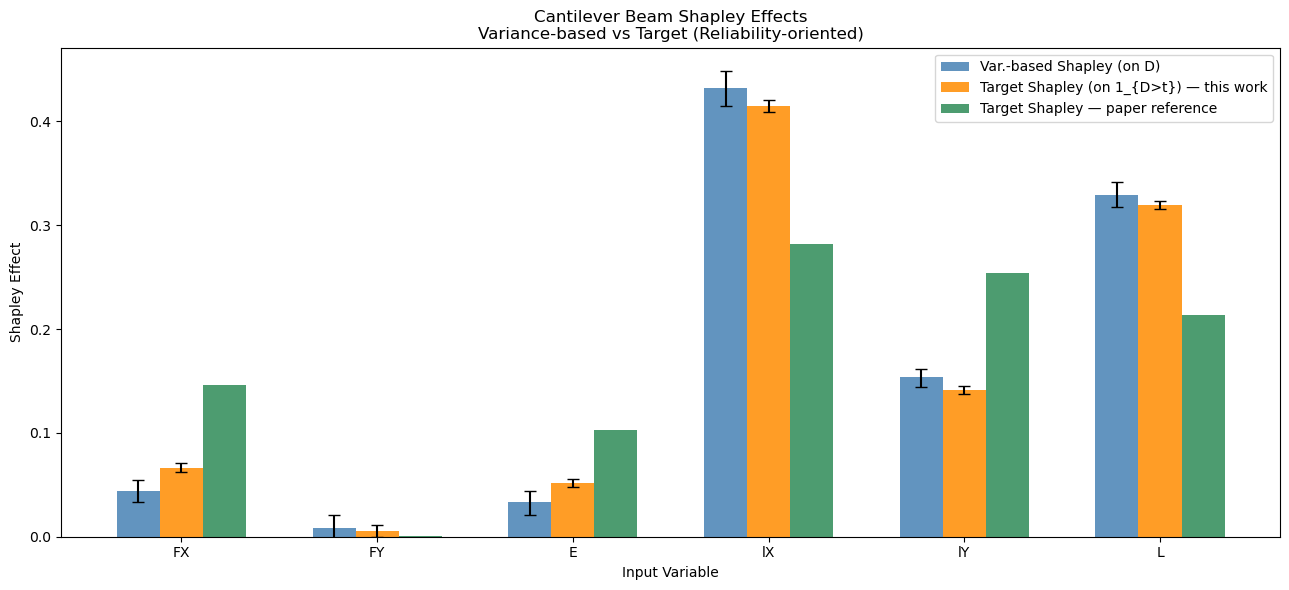

In [12]:
fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.18
x = np.arange(d)

ax.bar(x - 1.5*bar_width, eff, bar_width,
       yerr=[eff - lower, upper - eff],
       capsize=3, color='steelblue', alpha=0.85,
       label='Var.-based (D, analytical)')
ax.bar(x - 0.5*bar_width, eff_t, bar_width,
       yerr=[eff_t - lower_t, upper_t - eff_t],
       capsize=3, color='darkorange', alpha=0.85,
       label='Target (1_{D>t}, analytical)')
ax.bar(x + 0.5*bar_width, mc_surrogate['effect'].values, bar_width,
       yerr=[mc_surrogate['effect'].values - mc_surrogate['lower'].values,
             mc_surrogate['upper'].values - mc_surrogate['effect'].values],
       capsize=3, color='seagreen', alpha=0.85,
       label='Var.-based (D, surrogate)')
ax.bar(x + 1.5*bar_width, ref_target_shap, bar_width,
       color='crimson', alpha=0.85,
       label='Target — paper reference')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Cantilever Beam Shapley Effects\nAnalytical vs RS-HDMR Surrogate vs Paper Reference')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Key Takeaways

1. **Gaussian copula with mixed marginals** enables Shapley effect
   estimation with correlated LogNormal + Normal inputs — the
   `GaussianCopulaMixed` wrapper handles the transformation between
   original and latent normal space transparently.
2. **RS-HDMR surrogate faithfully reproduces analytical results** —
   trained on only 512 uniform samples, the surrogate recovers
   variance-based Shapley effects nearly identical to the analytical
   function, even though the deployment distribution (correlated
   mixed LogNormal+Normal) differs from the training distribution
   (independent uniform).
3. **Variance-based vs target Shapley differ** — variance-based
   effects measure sensitivity of the deflection magnitude; target
   effects measure sensitivity of *failure occurrence*.  Rankings
   can differ because the failure region is in the tail.
4. **Dimensional parameters dominate** — $l_X$, $l_Y$, and $L$
   are the most influential inputs in all analyses.
5. **Why target Shapley differs from the paper:**
   - The paper uses *exact conditional sampling* (Appendix I);
     this notebook uses a Gaussian copula approximation.
   - $p_f \\approx 0.07$ (copula) vs $p_f \\approx 0.015$ (paper)
     confirms different tail behaviour.
   - Exact replication requires sampling from true conditional
     distributions of LogNormal+Normal mixtures.